# Cartorgraphie statistique avec python

<fieldset>
<p>Ce carnet a pour objectif de présenter quelques paquets constitutifs de l'écosystème python dédié à la cartographie.</p>
<p>Deux cas de figure sont présentés :</p>
<ul>
<li>une carte en cercles proprotionnels en utilisant un service en ligne pour fournir le fond de carte,</li>
<li>une carte choroplèthe à partir d'un <i>shapefile</i> pour le fond de carte.</li>
</ul>
</fieldset>

## Quelques remarques sur les librairies

Pour ce carnet, nous utiliserons :

- [GeoPandas](https://geopandas.org/en/stable/index.html) : extension `pandas` qui étand le principe des dataframes aux données spatialisées grâce à l'objet `GeoDataFrame`.
- [mapclassify](https://pysal.org/mapclassify/) qui permet de discrétiser des cartes choroplèthes.
- [contextily](https://contextily.readthedocs.io/en/latest/intro_guide.html) pour utiliser des *tuiles* de services de cartographie en ligne afin de constituer des fonds de carte.
- [Shapely](https://shapely.readthedocs.io/en/stable/) pour manipuler des objets géométriques spatialisées.
- `matplotlib` pour tracer les graphiques contenant les cartes.

In [1]:
!pip install geopandas matplotlib mapclassify contextily

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify
import numpy as np
import contextily as cx

## Scénario 1 : carte en cercles proportionnels

Nous allons utiliser le jeu de données des  [déplacements des présidents de la République et des premiers ministres depuis 1945](https://data.culture.gouv.fr/explore/dataset/deplacements-presidents-republique-et-premiers-ministres-depuis-1945/information/) mis à disposition par les Archives Nationales.

Commençons par récupérer les données et les décrire rapidement :

In [3]:
url = "https://data.culture.gouv.fr/api/explore/v2.1/catalog/datasets/deplacements-presidents-republique-et-premiers-ministres-depuis-1945/exports/csv?lang=fr&timezone=Europe%2FBerlin&use_labels=true&delimiter=%3B"
df = pd.read_csv(url, sep=";")

In [4]:
df.head()

,Fonction,Individu,Contenu initial,Lieu,Lieu normalisé,Pays,Code pays,Date de début,Année du voyage,Date de fin,Lieu (contours),URL de la notice,Cote du dossier,geo_point_2d
0,Président de la République,Valéry Giscard d'Estaing,"Côte d'Ivoire, 11-15 janvier 1978 (deux dossiers)",Côte d'Ivoire,NaN,Côte d'Ivoire,CIV,1978-01-11,1978,1978-01-15,"{""coordinates"": [[[[-2.685564, 9.481818], [-2....",http://www.siv.archives-nationales.culture.gou...,19860020/66,"7.631309751595021, -5.564109742226817"
1,Premier ministre,Raymond Barre,"Paris, salon du meuble, 15 janvier 1979",Paris,Paris (département),France,FRA,1979-01-15,1979,NaN,"{""coordinates"": [[[2.319884458526643, 48.90045...",https://www.siv.archives-nationales.culture.go...,19860020/21,"48.85659797352162, 2.3426475364340966"
2,Premier ministre,Jean-Pierre Raffarin,"Déplacement privé en Suisse, du 23 au 25 août ...",Suisse,NaN,Suisse,CHE,2003-08-23,2003,2003-08-25,"{""coordinates"": [[[[10.471236, 46.871354], [10...",https://www.siv.archives-nationales.culture.go...,20160201/38,"46.79856545578162, 8.230169475165207"
3,Président de la République,Jacques Chirac,Berlin (Allemagne) le 3 mai 2007.,Allemagne,NaN,Allemagne,DEU,NaN,2007,2006-10-28,"{""coordinates"": [[[[9.445354, 54.8254], [9.972...",https://www.siv.archives-nationales.culture.go...,20220621/4,"51.09747327692469, 10.400329133037495"
4,Président de la République,François Hollande,"Ryad (Arabie saoudite), les 29 et 30 décembre ...",Ryad,NaN,Arabie saoudite,SAU,2013-12-29,2013,2013-12-30,"{""coordinates"": [[[[51.584227, 24.260464], [52...",http://www.siv.archives-nationales.culture.gou...,20250096/42,"24.130367908708784, 44.54310128006917"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2750 entries, 0 to 2749
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Fonction          2750 non-null   object
 1   Individu          2750 non-null   object
 2   Contenu initial   2750 non-null   object
 3   Lieu              2750 non-null   object
 4   Lieu normalisé    1493 non-null   object
 5   Pays              2750 non-null   object
 6   Code pays         2750 non-null   object
 7   Date de début     2648 non-null   object
 8   Année du voyage   2750 non-null   int64 
 9   Date de fin       1430 non-null   object
 10  Lieu (contours)   2738 non-null   object
 11  URL de la notice  2750 non-null   object
 12  Cote du dossier   2750 non-null   object
 13  geo_point_2d      2738 non-null   object
dtypes: int64(1), object(13)
memory usage: 300.9+ KB


Le jeu de données est assez important avec un total de 2750 visites officielles.

Pour la suite, nous allons sélectionner quelques villes françaises pour constituer un échantillon.

In [6]:
df_sel = df[df['Lieu'].isin(["Cannes", "Besançon",
                             "Béziers", "Chartres",
                             "Clermont-Ferrand", "Dijon",
                             "Lyon", "Strasbourg",
                             "Lille", "Nantes"])]

In [7]:
df_sel

,Fonction,Individu,Contenu initial,Lieu,Lieu normalisé,Pays,Code pays,Date de début,Année du voyage,Date de fin,Lieu (contours),URL de la notice,Cote du dossier,geo_point_2d
26,Premier ministre,Raymond Barre,"Lyon, 8 et 22 septembre, 4 octobre 1978",Lyon,Rhône (département),France,FRA,1978-10-04,1978,NaN,"{""coordinates"": [[[4.780454635853134, 46.17691...",https://www.siv.archives-nationales.culture.go...,19860020/20,"45.871153980415556, 4.640783179841645"
96,Président de la République,François Mitterrand,Lille le 18 mai 1993,Lille,Nord (département),France,FRA,1993-05-18,1993,NaN,"{""coordinates"": [[[[3.003934263266177, 50.1501...",http://www.siv.archives-nationales.culture.gou...,19980060/6,"50.448628924055015, 3.2139409958298546"
99,Premier ministre,Lionel Jospin,"Strasbourg, 31 janvier 2001",Strasbourg,Bas-Rhin (département),France,FRA,2001-01-31,2001,NaN,"{""coordinates"": [[[7.198281537029947, 48.31046...",https://www.siv.archives-nationales.culture.go...,20050317/18,"48.672739532612006, 7.5507840362458785"
139,Premier ministre,Pierre Messmer,"Lyon, 30-31 janvier 1974",Lyon,Rhône (département),France,FRA,1974-01-30,1974,1974-01-31,"{""coordinates"": [[[4.780454635853134, 46.17691...",https://www.siv.archives-nationales.culture.go...,19860020/18,"45.871153980415556, 4.640783179841645"
143,Premier ministre,Édouard Balladur,"Strasbourg, 31 janvier 1995",Strasbourg,Bas-Rhin (département),France,FRA,1995-01-31,1995,NaN,"{""coordinates"": [[[7.198281537029947, 48.31046...",https://www.siv.archives-nationales.culture.go...,20040093/10,"48.672739532612006, 7.5507840362458785"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2530,Premier ministre,Dominique de Villepin,"Dijon, le 28 octobre 2005",Dijon,Côte-d'Or (département),France,FRA,2005-10-28,2005,NaN,"{""coordinates"": [[[[4.115965713730382, 47.1233...",https://www.siv.archives-nationales.culture.go...,20160201/33,"47.427113437240195, 4.772578236835473"
2608,Président de la République,François Mitterrand,Annonce de la liaison franco-britannique trans...,Lille,Nord (département),France,FRA,1986-01-20,1986,NaN,"{""coordinates"": [[[[3.003934263266177, 50.1501...",http://www.siv.archives-nationales.culture.gou...,19940280/10,"50.448628924055015, 3.2139409958298546"
2674,Premier ministre,Lionel Jospin,"Strasbourg, Conseil de l'Europe, 10-11 octobre...",Strasbourg,Bas-Rhin (département),France,FRA,1997-10-10,1997,1997-10-11,"{""coordinates"": [[[7.198281537029947, 48.31046...",https://www.siv.archives-nationales.culture.go...,20050317/1,"48.672739532612006, 7.5507840362458785"
2677,Premier ministre,Lionel Jospin,"Cannes (Alpes-Maritimes), 10 mai 2000",Cannes,Alpes-Maritimes (département),France,FRA,2000-05-10,2000,NaN,"{""coordinates"": [[[6.933459342395495, 43.48030...",https://www.siv.archives-nationales.culture.go...,20050317/15,"43.93816145538295, 7.116224536521471"


Nous allons nous intéresser à la colonne `Lieu` qui désigne les villes où des visites officielles se sont déroulées et pour laquelle nous disposons des coordonnées géographiques dans la colonne `geo_point_2d` :

In [8]:
df_lieux = df_sel.groupby(by=["geo_point_2d"]).size().reset_index(name='eff')
df_lieux

,geo_point_2d,eff
0,"43.5797034156242, 3.3670850959773513",2
1,"43.93816145538295, 7.116224536521471",3
2,"45.725914009643354, 3.1404246784456067",7
3,"45.871153980415556, 4.640783179841645",42
4,"47.16533763675472, 6.361508410031178",6
5,"47.36115270183291, -1.6846197278010553",10
6,"47.427113437240195, 4.772578236835473",5
7,"48.38812347601921, 1.370095442769078",6
8,"48.672739532612006, 7.5507840362458785",32
9,"50.448628924055015, 3.2139409958298546",15


Découpons la colonne des coordonnées en deux colonnes lat, long distinctes :

In [9]:
df_lieux[['lon','lat']] = df_lieux.geo_point_2d.str.split(",",expand=True)
df_lieux

,geo_point_2d,eff,lon,lat
0,"43.5797034156242, 3.3670850959773513",2,43.5797034156242,3.3670850959773513
1,"43.93816145538295, 7.116224536521471",3,43.93816145538295,7.116224536521471
2,"45.725914009643354, 3.1404246784456067",7,45.725914009643354,3.1404246784456067
3,"45.871153980415556, 4.640783179841645",42,45.871153980415556,4.640783179841645
4,"47.16533763675472, 6.361508410031178",6,47.16533763675472,6.361508410031178
5,"47.36115270183291, -1.6846197278010553",10,47.36115270183291,-1.6846197278010553
6,"47.427113437240195, 4.772578236835473",5,47.427113437240195,4.772578236835473
7,"48.38812347601921, 1.370095442769078",6,48.38812347601921,1.370095442769078
8,"48.672739532612006, 7.5507840362458785",32,48.672739532612006,7.5507840362458785
9,"50.448628924055015, 3.2139409958298546",15,50.448628924055015,3.2139409958298546


Et utilisons maintenant geopanas pour construire un *geodataframe*.

In [11]:
gdf = gpd.GeoDataFrame(
    df_lieux,
    geometry=gpd.points_from_xy(df_lieux["lat"], df_lieux["lon"]),
    crs="EPSG:4326"
)

On change le système de projection, car les fonds de carte que nous allons téléchargés avec contextily sont en `EPSG:3857`.

In [12]:
gdf = gdf.to_crs(epsg=3857)

On utilise `shapely` pour délimiter un cadre correspondant aux limites de la france métropolitaine.

In [13]:
from shapely.geometry import box

In [14]:
bbox_fr = gpd.GeoSeries(
    [box(-5.5, 41.0, 9.8, 51.5)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

xmin, ymin, xmax, ymax = bbox_fr.total_bounds

On calcule la racine carrée de effectif (puissance 0.5) et on multiplie ces résultats par 50 afin d'avoir des cercles suffisamment visibles sur le carte finale.

In [15]:
sizes = (df_lieux["eff"] ** 0.5) * 50
sizes

,eff
0,70.710678
1,86.602540
2,132.287566
3,324.037035
4,122.474487
5,158.113883
6,111.803399
7,122.474487
8,282.842712
9,193.649167


Il n'y a alors plus qu'à écrire le code pour générer la carte et la légende avec `matplotlib` :

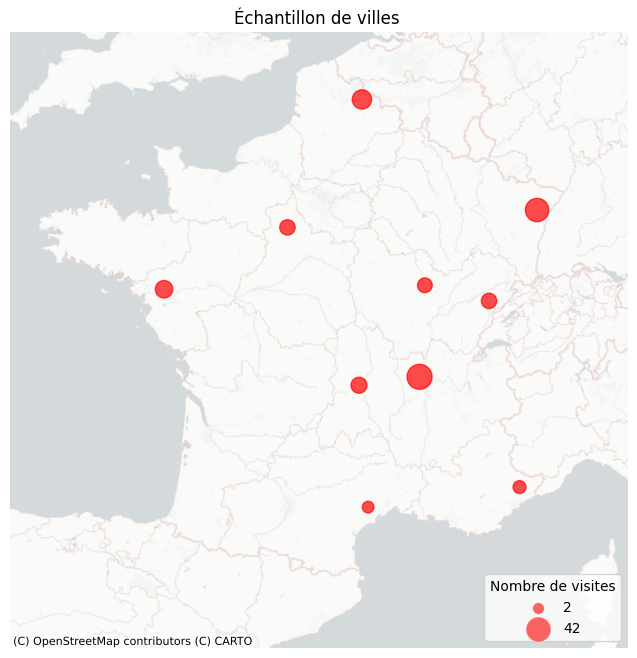

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

h1 = ax.scatter([], [], s=min(sizes), color="red", alpha=0.6, edgecolors="white", linewidth=0.5)
h2 = ax.scatter([], [], s=max(sizes), color="red", alpha=0.6, edgecolors="white", linewidth=0.5)

labels = [
    f"{int(min(df_lieux["eff"]))}",
    f"{int(max(df_lieux["eff"]))}"
]

ax.legend(
    [h1, h2],
    labels,
    title="Nombre de visites",
    scatterpoints=1,
    loc="lower right",
    frameon=True
)

gdf.plot(ax=ax,
         markersize=sizes,
         color="red",
         alpha=0.7)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)
ax.set_axis_off()
plt.title("Échantillon de villes ")
plt.show()

Pour exporter la carte en PNG :

In [125]:
plt.savefig("carte.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Scénario 2 : carte choroplèthe depuis un CSV en utilisant un shapefile

Nous allon sprendre l'exemple de données à l'échelle départementale pour la france des années 1830 qui se prêtent à la fois à des analyses quantitatives et à des représentations cartographiques. Ces chiffres proviennent de sources classiques comme l'enquête d'André-Michel Guerry de 1833 sur la statistique morale de la France ou bien l'essai d'Adolphe Angeville sur la statistique de la population française de 1836.

Ces données sont notamment présentes dans les paquets R [Guerry](https://cran.r-project.org/web/packages/Guerry/index.html) ou bien [HistData](https://cran.r-project.org/web/packages/HistData/index.html).

Ici c'est un cas de figure où les données sont dans un CSV où une ligne est un département et le fond de carte correspondant est un *shapefile*. Le but est de produire une carte choroplèthe à l'échelle départementale à partir d'une des variables du CSV. Cela implique de faire une jointure entre le tableau des données et le *shapefile*.

D'abord, téléchargeons le fond de carte :

In [17]:
!wget https://github.com/PirehP1/intro_cartographie_python/raw/refs/heads/main/dep_1815.zip

--2026-05-24 08:53:41--  https://github.com/PirehP1/intro_cartographie_python/raw/refs/heads/main/dep_1815.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/PirehP1/intro_cartographie_python/refs/heads/main/dep_1815.zip [following]
--2026-05-24 08:53:42--  https://raw.githubusercontent.com/PirehP1/intro_cartographie_python/refs/heads/main/dep_1815.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18973 (19K) [application/zip]
Saving to: ‘dep_1815.zip’

dep_1815.zip        100%[===================>]  18.53K  --.-KB/s    in 0s      

2026-05-24 08:53:42 (70.1 MB/s) - ‘dep_1815.zip’ saved [1897

Et décompressons l'archive zip pour créer un répertoire `dep_1815` avec les différents fichiers du *shapefile* :

In [18]:
!unzip /content/dep_1815.zip -d /content/

Archive:  /content/dep_1815.zip
   creating: /content/dep_1815/
  inflating: /content/dep_1815/dep_1815.shp  
  inflating: /content/dep_1815/dep_1815.shx  
  inflating: /content/dep_1815/dep_1815.dbf  
  inflating: /content/dep_1815/dep_1815.cpg  
  inflating: /content/dep_1815/dep_1815.qmd  


Utilisons ensuite `geopandas` pour charger le *shapefile* des départements français après 1815 (qui ici n'est pas géoréférencé).

In [19]:
gdf = gpd.read_file("/content/dep_1815/dep_1815.shp")

On peut utiliser `matplotlib` pour faire une première projection du *shapefile*.

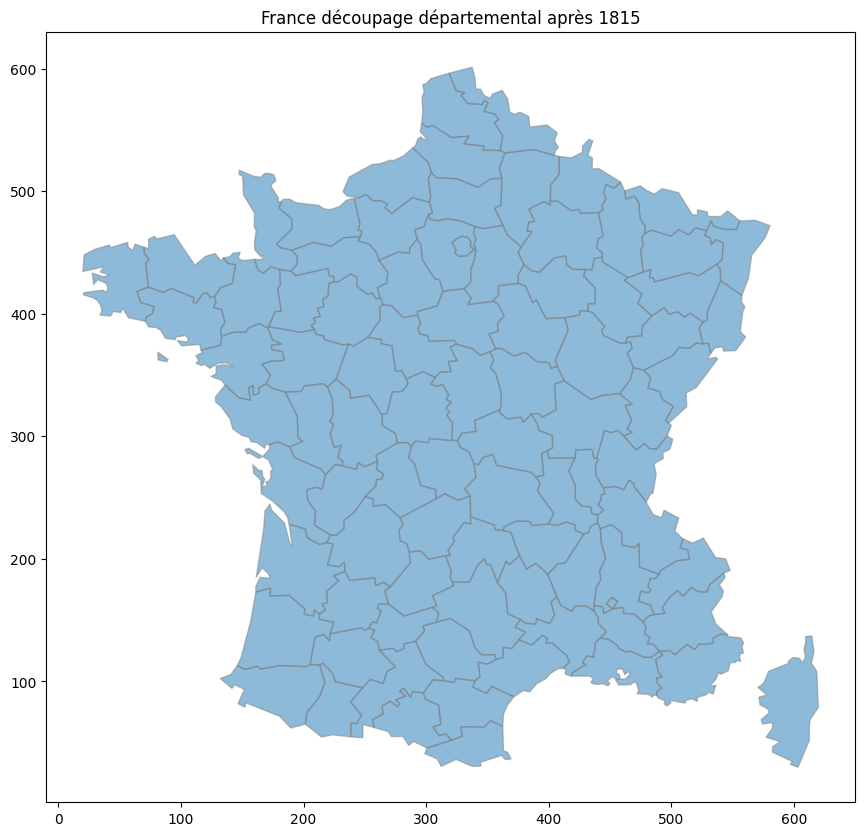

In [20]:
gdf.plot(figsize=(12, 10), edgecolor='gray', alpha=0.5)
plt.title("France découpage départemental après 1815")
plt.show()

Passons maintenant au CSV contenant les données que l'on charge ici comme un *dataframe* `pandas`.

In [21]:
url = "https://github.com/PirehP1/intro_cartographie_python/raw/refs/heads/main/data_france_1830.csv"
df = pd.read_csv(url, sep=";", decimal=",")

On peut avoir un aperçu du contenu via les méthodes `.head()` et `.info()`.
On constate que l'on a 6 variables quantitatives, une colonne `DEPT` qui sert ici d'identifiant et une colonne avec le nom des départements.

La colonne `DEPT` est au format *int64*.

In [22]:
df.head()

,DEPT,Departement,Agriculteurs,Industriels,Ecoliers,Esperance_de_vie,Densite_industrie,Pauperisme
0,1,Ain,706,99,39,34.9,5.3,8
1,2,Aisne,288,495,78,37.5,7.3,35
2,3,Allier,601,179,12,32.3,6.5,3
3,4,Basses-Alpes,679,159,45,31.9,5.1,11
4,5,Hautes-Alpes,733,81,76,31.7,3.0,8


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DEPT               86 non-null     int64  
 1   Departement        86 non-null     object 
 2   Agriculteurs       86 non-null     int64  
 3   Industriels        86 non-null     int64  
 4   Ecoliers           86 non-null     int64  
 5   Esperance_de_vie   86 non-null     float64
 6   Densite_industrie  86 non-null     float64
 7   Pauperisme         86 non-null     int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 5.5+ KB


Si l'on fait de même avec le *shapefile* on constate que la colonne `IDENT` qui correspond aux identifiants des polygones des départements est un *object* qui contient des *strings*.

In [24]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   IDEN      87 non-null     object  
 1   geometry  87 non-null     geometry
dtypes: geometry(1), object(1)
memory usage: 1.5+ KB


Nous avons donc un problème pour faire la jointure entre le *dataframe* des données et le *geodataframe* contenant le *shapefile* : il faut que les identifiants respectifs soient dans le même format. Pour simplifier les choses nous allons également donner le même nom aux colonnes des identifiants.

In [25]:
df.rename(columns = {"DEPT": "IDEN"},
          inplace = True)

In [26]:
convert_dict = {'IDEN': str}
df = df.astype(convert_dict)

On vérifie que tout a bien fonctionné :

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IDEN               86 non-null     object 
 1   Departement        86 non-null     object 
 2   Agriculteurs       86 non-null     int64  
 3   Industriels        86 non-null     int64  
 4   Ecoliers           86 non-null     int64  
 5   Esperance_de_vie   86 non-null     float64
 6   Densite_industrie  86 non-null     float64
 7   Pauperisme         86 non-null     int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 5.5+ KB


Il n'y a alors plus qu'à faire la jointure, ici via la méthode `.merge()` :

In [28]:
gdf = gdf.merge(df, on='IDEN')

Il nous reste à discrétiser une des variables et à projeter le résultat sur une carte. Ici nous utilisons l'algorithme de Jenks pour une discrétisation en 5 classes. Ici `geopandas` fait appel à la librairie [`mapclassify`](https://pysal.org/mapclassify) pour tout ce qui est discrétisation.

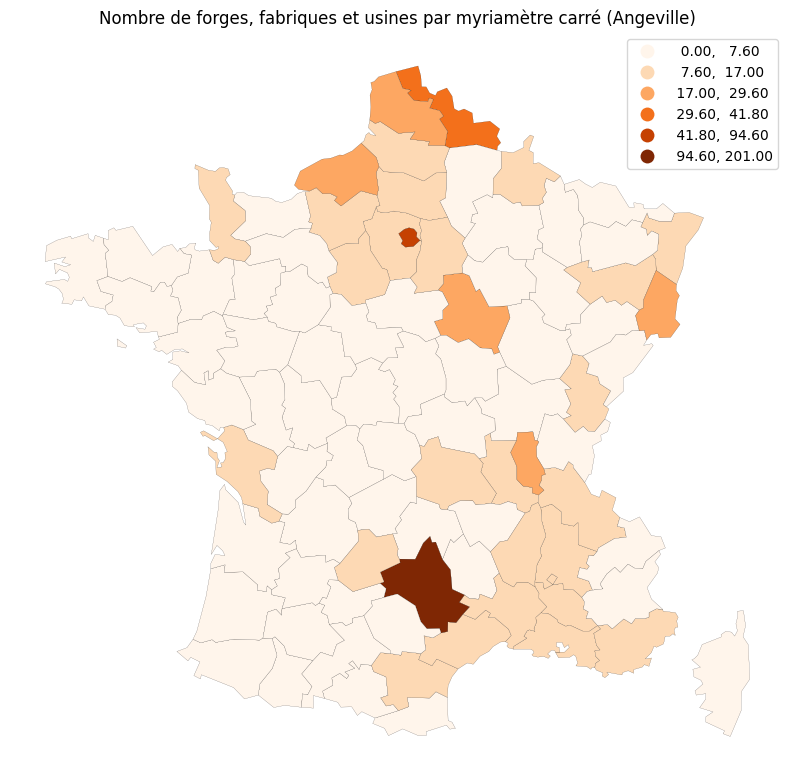

In [29]:
gdf.plot(column="Densite_industrie",
         scheme="fisher_jenks",
         k=6,
         cmap='Oranges',
         legend=True,
         linewidth=0.1,
         edgecolor="black",
         figsize=(10, 10)
        )
plt.title("Nombre de forges, fabriques et usines par myriamètre carré (Angeville)")
plt.axis('off')
plt.show()

La légenge générée est correcte, mais n'est pas conformes aux conventions pour une carte finalisée. Si l'on veut améliorer les choses, on peut reproduire la procédure décrite dans la [documentation de `mapclassify`](https://nbviewer.org/github/pysal/mapclassify/blob/main/notebooks/03_choropleth.ipynb).